In [18]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset
from transformers import ViTModel, ViTFeatureExtractor
from torch import nn, optim
from tqdm import tqdm
import numpy as np
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load and preprocess CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize as expected by ViT
])

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Reduce dataset size (e.g., use 20% of the full dataset)
subset_fraction = 0.1  # Use 10% of the original dataset
subset_size = int(len(dataset) * subset_fraction)
indices = np.random.choice(len(dataset), subset_size, replace=False)
dataset = Subset(dataset, indices)

# Split ratios for ablation study
split_ratios = [
    (0.6, 0.1, 0.3), (0.6, 0.3, 0.1), (0.6, 0.2, 0.2),
    (0.5, 0.1, 0.4), (0.5, 0.4, 0.1), (0.5, 0.25, 0.25)
]

def create_splits(dataset, ratios):
    total_size = len(dataset)
    split_sizes = [int(r * total_size) for r in ratios]
    split_sizes[-1] = total_size - sum(split_sizes[:-1])  # Adjust the last split size
    return random_split(dataset, split_sizes)

# Load pretrained ViT model and freeze parameters
base_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k").to(device)
for param in base_model.parameters():
    param.requires_grad = False

# Add classification head
class ViTClassifier(nn.Module):
    def __init__(self, base_model, num_classes=10):
        super(ViTClassifier, self).__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(base_model.config.hidden_size, num_classes)

    def forward(self, x):
        outputs = self.base_model(pixel_values=x)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS token representation
        return self.classifier(pooled_output)

model = ViTClassifier(base_model).to(device)

# Training and evaluation functions
def train_and_evaluate(split_ratios, epochs=5, batch_size=16, lr=1e-3):
    results = {}
    for split in split_ratios:
        print(f"\n--- Training with split {split} ---")
        train_data, val_data, test_data = create_splits(dataset, split)

        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

        # Optimizer and loss function
        optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        # Training loop
        for epoch in range(epochs):
            model.train()
            train_loss, train_correct = 0, 0
            for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                train_correct += (outputs.argmax(dim=1) == labels).sum().item()

            # Validation loop
            model.eval()
            val_loss, val_correct = 0, 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    val_correct += (outputs.argmax(dim=1) == labels).sum().item()

            # Print epoch results
            train_acc = train_correct / len(train_data)
            val_acc = val_correct / len(val_data)
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"Train Loss = {train_loss/len(train_loader):.4f}, "
                  f"Train Acc = {train_acc:.4f}, "
                  f"Val Loss = {val_loss/len(val_loader):.4f}, "
                  f"Val Acc = {val_acc:.4f}")

        # Testing
        model.eval()
        test_correct = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                test_correct += (outputs.argmax(dim=1) == labels).sum().item()

        test_acc = test_correct / len(test_data)
        print(f"Test Accuracy for split {split}: {test_acc:.4f}")

        # Store results
        results[split] = test_acc
    return results

# Run the training and evaluation
results = train_and_evaluate(split_ratios)

# Print final results
print("\n--- Final Results ---")
for split, acc in results.items():
    print(f"Split {split}: Test Accuracy = {acc:.4f}")


Using device: cuda
Files already downloaded and verified

--- Training with split (0.6, 0.1, 0.3) ---


Epoch 1/5: 100%|██████████| 188/188 [00:36<00:00,  5.19it/s]


Epoch 1/5: Train Loss = 0.9470, Train Acc = 0.8967, Val Loss = 0.3716, Val Acc = 0.9480


Epoch 2/5: 100%|██████████| 188/188 [00:36<00:00,  5.08it/s]


Epoch 2/5: Train Loss = 0.2691, Train Acc = 0.9677, Val Loss = 0.2265, Val Acc = 0.9500


...

Epoch 3/5: Train Loss = 0.0199, Train Acc = 0.9980, Val Loss = 0.0354, Val Acc = 0.9888


Epoch 4/5: 100%|██████████| 157/157 [00:29<00:00,  5.26it/s]


Epoch 4/5: Train Loss = 0.0173, Train Acc = 0.9984, Val Loss = 0.0365, Val Acc = 0.9880


Epoch 5/5: 100%|██████████| 157/157 [00:29<00:00,  5.26it/s]


Epoch 5/5: Train Loss = 0.0148, Train Acc = 0.9984, Val Loss = 0.0374, Val Acc = 0.9880
Test Accuracy for split (0.5, 0.25, 0.25): 0.9936

--- Final Results ---
Split (0.6, 0.1, 0.3): Test Accuracy = 0.9713
Split (0.6, 0.3, 0.1): Test Accuracy = 0.9580
Split (0.6, 0.2, 0.2): Test Accuracy = 0.9820
Split (0.5, 0.1, 0.4): Test Accuracy = 0.9875
Split (0.5, 0.4, 0.1): Test Accuracy = 0.9880
Split (0.5, 0.25, 0.25): Test Accuracy = 0.9936


In [ ]:
# Load the pretrained ViT model
base_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k").to(device)

# Print the model architecture
print(base_model)

ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTSdpaAttention(
          (attention): ViTSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUAct

# **Architecture**

# 1.) Embeddings
*   Images are divided into patches (16*16) and each patch is flattened and projected into a 1D embedding space using a convolutional layer.

# 2.) Encoder


*  Consists of 12 ViT Layers each containing Self-Attention, Intermediate Layer and Output Layer. Normalization layers are applied.

# 3.) Pooler


*   Extracts final feature vector for classification . Tanh activation function is applied.







Using device: cuda
Files already downloaded and verified

--- Training with earlier Fine-Tuning Configuration ---


Epoch 1/5: 100%|██████████| 157/157 [00:26<00:00,  5.85it/s]


Epoch 1 - Train Loss: 1.0500
Epoch 1 - Validation Loss: 0.4578


Epoch 2/5: 100%|██████████| 157/157 [00:27<00:00,  5.65it/s]


Epoch 2 - Train Loss: 0.3083
Epoch 2 - Validation Loss: 0.2569


...

Epoch 3 - Train Loss: 0.0225
Epoch 3 - Validation Loss: 0.0396


Epoch 4/5: 100%|██████████| 157/157 [00:30<00:00,  5.19it/s]


Epoch 4 - Train Loss: 0.0197
Epoch 4 - Validation Loss: 0.0401


Epoch 5/5: 100%|██████████| 157/157 [00:30<00:00,  5.18it/s]


Epoch 5 - Train Loss: 0.0168
Epoch 5 - Validation Loss: 0.0411


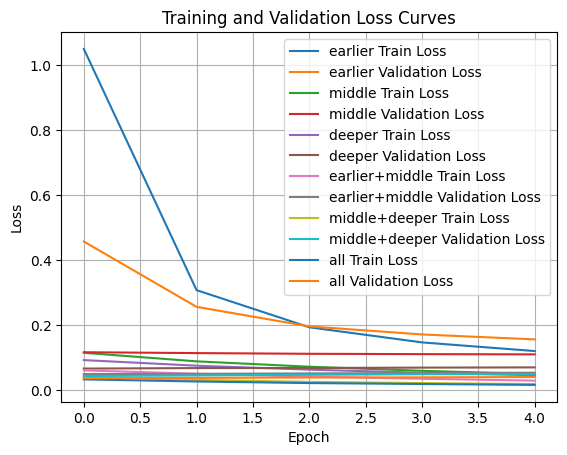

Config: earlier
Accuracy: 0.9640, F1-score: 0.9641, Precision: 0.9645, Recall: 0.9640, AUC-ROC: 0.9988
Config: middle
Accuracy: 0.9560, F1-score: 0.9561, Precision: 0.9569, Recall: 0.9560, AUC-ROC: 0.9989
Config: deeper
Accuracy: 0.9820, F1-score: 0.9820, Precision: 0.9821, Recall: 0.9820, AUC-ROC: 0.9993
Config: earlier+middle
Accuracy: 0.9800, F1-score: 0.9800, Precision: 0.9804, Recall: 0.9800, AUC-ROC: 0.9993
Config: middle+deeper
Accuracy: 0.9820, F1-score: 0.9819, Precision: 0.9824, Recall: 0.9820, AUC-ROC: 0.9994
Config: all
Accuracy: 0.9940, F1-score: 0.9940, Precision: 0.9940, Recall: 0.9940, AUC-ROC: 0.9999


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset
from transformers import ViTModel
from torch import nn, optim
from tqdm import tqdm
import numpy as np
import random
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load and preprocess CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize as expected by ViT
])

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Reduce dataset size (e.g., use 10% of the full dataset)
subset_fraction = 0.1
subset_size = int(len(dataset) * subset_fraction)
indices = np.random.choice(len(dataset), subset_size, replace=False)
dataset = Subset(dataset, indices)

# Fixed split ratios: 50% train, 40% validation, 10% test
def create_splits(dataset, ratios=(0.5, 0.4, 0.1)):
    total_size = len(dataset)
    split_sizes = [int(r * total_size) for r in ratios]
    split_sizes[-1] = total_size - sum(split_sizes[:-1])  # Adjust the last split size
    return random_split(dataset, split_sizes)

# Load pretrained ViT model and freeze parameters
base_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k").to(device)
for param in base_model.parameters():
    param.requires_grad = False

# Add classification head
class ViTClassifier(nn.Module):
    def __init__(self, base_model, num_classes=10):
        super(ViTClassifier, self).__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(base_model.config.hidden_size, num_classes)

    def forward(self, x):
        outputs = self.base_model(pixel_values=x)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS token representation
        return self.classifier(pooled_output)

model = ViTClassifier(base_model).to(device)

# Function to fine-tune specific layers based on configuration
def fine_tune_layers(model, config):
    for name, param in model.named_parameters():
        if "embeddings" in name:  # Freeze embedding layers
            param.requires_grad = False
        if "encoder.layer.0" in name and config != "earlier":
            param.requires_grad = False
        if "encoder.layer.5" in name and config not in ["middle", "earlier+middle", "middle+deeper", "all"]:
            param.requires_grad = False
        if "encoder.layer.10" in name and config not in ["deeper", "middle+deeper", "all"]:
            param.requires_grad = False
        if "pooler" in name:  # Fine-tune pooler layer
            param.requires_grad = True

# Cross-Entropy Loss function
criterion = nn.CrossEntropyLoss()

# Evaluation function
def evaluate_model(model, data_loader):
    model.eval()
    correct, total, all_preds, all_labels, all_probs = 0, 0, [], [], []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = correct / total
    classification_metrics = classification_report(all_labels, all_preds, output_dict=True)

    # Calculate AUC-ROC
    auc_roc = roc_auc_score(all_labels, np.array(all_probs), multi_class="ovr", average="macro")

    return accuracy, classification_metrics, auc_roc

# Training and evaluation for each configuration
def train_and_evaluate_with_configurations(configurations, epochs=5, batch_size=16):
    results = {}
    for config in configurations:
        print(f"\n--- Training with {config} Fine-Tuning Configuration ---")
        fine_tune_layers(model, config)

        # Split the dataset
        train_data, val_data, test_data = create_splits(dataset, ratios=(0.5, 0.4, 0.1))
        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

        # Optimizer setup
        optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

        # Tracking training and validation losses
        train_losses = []
        val_losses = []

        # Training Loop
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0.0
            for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_epoch_loss)
            print(f"Epoch {epoch + 1} - Train Loss: {avg_epoch_loss:.4f}")

            # Validation loss
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            print(f"Epoch {epoch + 1} - Validation Loss: {avg_val_loss:.4f}")

        # Evaluate on Test Set
        test_accuracy, metrics, auc_roc = evaluate_model(model, test_loader)

        # Store results
        results[config] = {
            "accuracy": test_accuracy,
            "f1_score": metrics["weighted avg"]["f1-score"],
            "precision": metrics["weighted avg"]["precision"],
            "recall": metrics["weighted avg"]["recall"],
            "auc_roc": auc_roc,
            "train_losses": train_losses,
            "val_losses": val_losses
        }

    return results

# Configurations for fine-tuning (layer combinations)
configurations = [
    "earlier", "middle", "deeper",
    "earlier+middle", "middle+deeper", "all"
]

# Run experiments for Cross-Entropy Loss
results = train_and_evaluate_with_configurations(configurations)

# Plot loss curves for both training and validation
for config, result in results.items():
    plt.plot(result["train_losses"], label=f"{config} Train Loss")
    plt.plot(result["val_losses"], label=f"{config} Validation Loss")

plt.title("Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# Print final results
for config, result in results.items():
    print(f"Config: {config}")
    print(f"Accuracy: {result['accuracy']:.4f}, F1-score: {result['f1_score']:.4f}, Precision: {result['precision']:.4f}, Recall: {result['recall']:.4f}, AUC-ROC: {result['auc_roc']:.4f}")


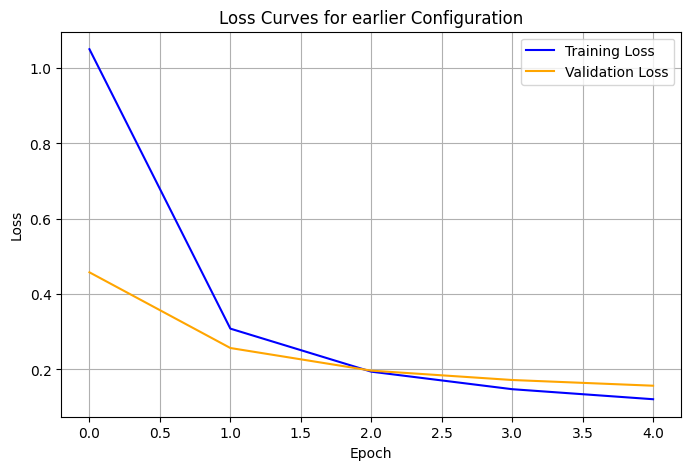

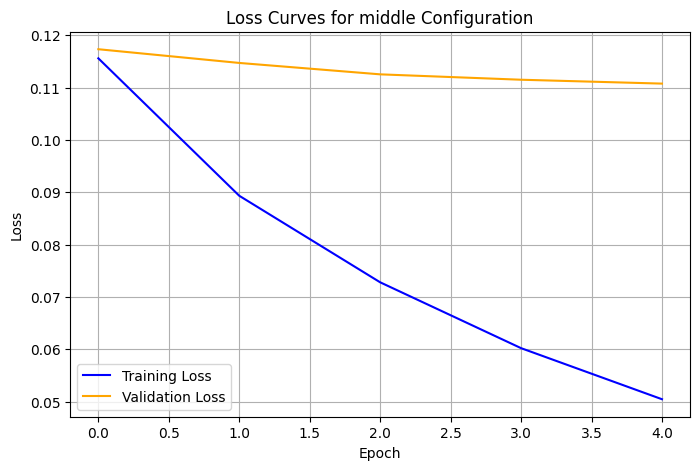

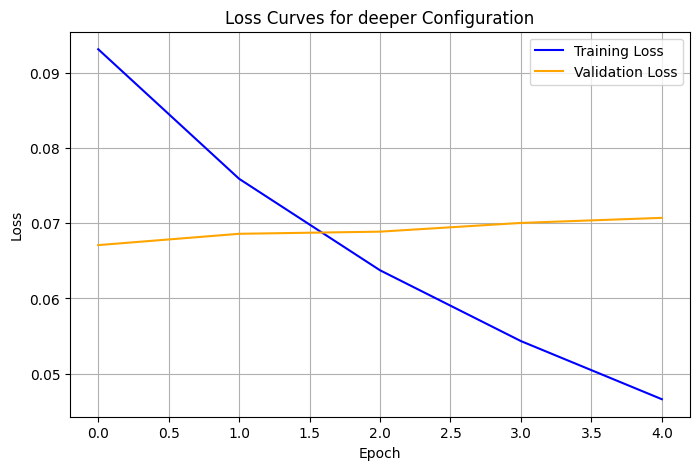

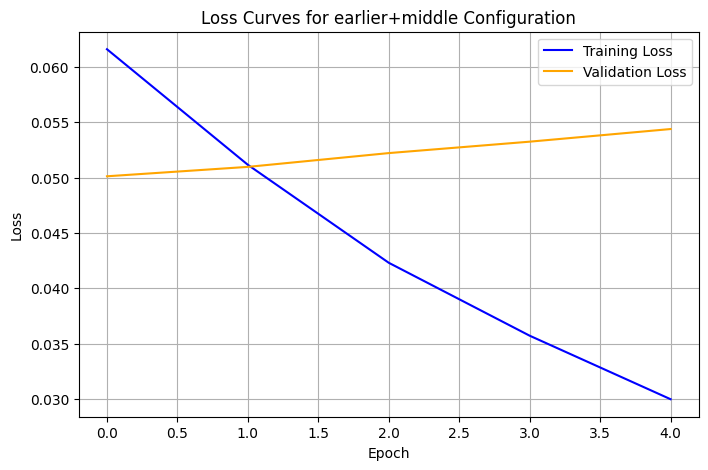

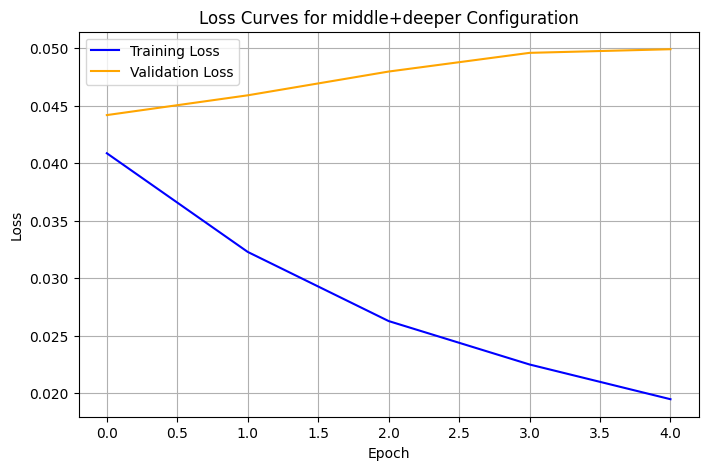

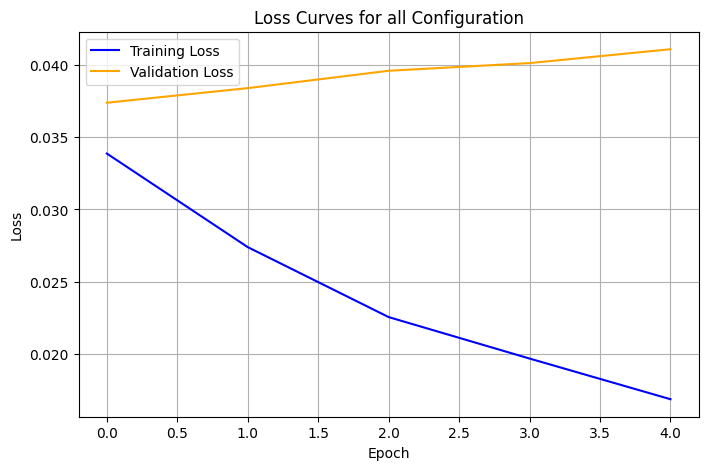

In [ ]:
# Plot loss curves for training and validation separately for each configuration
for config, result in results.items():
    plt.figure(figsize=(8, 5))
    plt.plot(result["train_losses"], label="Training Loss", color="blue")
    plt.plot(result["val_losses"], label="Validation Loss", color="orange")
    plt.title(f"Loss Curves for {config} Configuration")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()


# Analysis of Loss for different configurations
Although the lowest loss is obtained for fine tuning all layers (and the best metrics as well) . The case also shows significant overfitting. Almost all cases show significant overfitting as the training loss decreases but the validation loss increases, remains constant or decreases very slightly, except for tuning earlier layer. Ideally, earlier configuration should be used for further analysis since, it has the least overfitting, but I have gone ahead with fine tuning all layers for now.

Using device: cuda
Files already downloaded and verified

--- Training with cross_entropy Loss Function ---


Epoch 1/5: 100%|██████████| 157/157 [00:27<00:00,  5.64it/s]


Epoch 1 | Train Loss: 1.0500, Val Loss: 0.4578


Epoch 2/5: 100%|██████████| 157/157 [00:28<00:00,  5.50it/s]


Epoch 2 | Train Loss: 0.3083, Val Loss: 0.2569


...

Epoch 3 | Train Loss: 0.6251, Val Loss: 0.6334


Epoch 4/5: 100%|██████████| 157/157 [00:29<00:00,  5.24it/s]


Epoch 4 | Train Loss: 0.6160, Val Loss: 0.6340


Epoch 5/5: 100%|██████████| 157/157 [00:29<00:00,  5.27it/s]


Epoch 5 | Train Loss: 0.6090, Val Loss: 0.6356


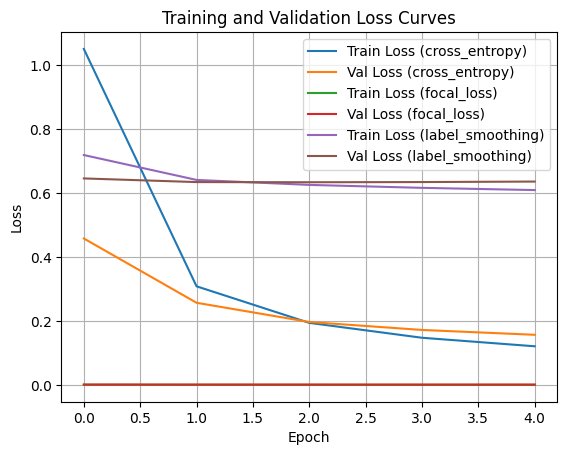

Loss Function: cross_entropy
Accuracy: 0.9640, F1-score: 0.9641, Precision: 0.9645, Recall: 0.9640, AUC-ROC: 0.9988
Loss Function: focal_loss
Accuracy: 0.9580, F1-score: 0.9580, Precision: 0.9586, Recall: 0.9580, AUC-ROC: 0.9989
Loss Function: label_smoothing
Accuracy: 0.9820, F1-score: 0.9820, Precision: 0.9822, Recall: 0.9820, AUC-ROC: 0.9991


In [24]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset
from transformers import ViTModel
from torch import nn, optim
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import random
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load and preprocess CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize as expected by ViT
])

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Reduce dataset size (e.g., use 10% of the full dataset)
subset_fraction = 0.1
subset_size = int(len(dataset) * subset_fraction)
indices = np.random.choice(len(dataset), subset_size, replace=False)
dataset = Subset(dataset, indices)

# Fixed split ratios: 50% train, 40% validation, 10% test
def create_splits(dataset, ratios=(0.5, 0.4, 0.1)):
    total_size = len(dataset)
    split_sizes = [int(r * total_size) for r in ratios]
    split_sizes[-1] = total_size - sum(split_sizes[:-1])  # Adjust the last split size
    return random_split(dataset, split_sizes)

# Load pretrained ViT model and freeze parameters
base_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k").to(device)
for param in base_model.parameters():
    param.requires_grad = False

# Add classification head
class ViTClassifier(nn.Module):
    def __init__(self, base_model, num_classes=10):
        super(ViTClassifier, self).__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(base_model.config.hidden_size, num_classes)

    def forward(self, x):
        outputs = self.base_model(pixel_values=x)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS token representation
        return self.classifier(pooled_output)

model = ViTClassifier(base_model).to(device)
# Different loss functions for experimentation
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, num_classes=10):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)  # Probability of correct class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Loss Functions
class LabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingLoss, self).__init__()
        self.smoothing = smoothing

    def forward(self, inputs, targets):
        n_class = inputs.size(1)
        one_hot = torch.zeros_like(inputs).scatter(1, targets.unsqueeze(1), 1)
        smooth_ones = 1.0 - self.smoothing
        smooth_zeros = self.smoothing / (n_class - 1)
        one_hot = one_hot * smooth_ones + smooth_zeros
        log_probs = F.log_softmax(inputs, dim=-1)
        loss = -(one_hot * log_probs).sum(dim=-1)
        return loss.mean()

class KLDivergenceLoss(nn.Module):
    def __init__(self):
        super(KLDivergenceLoss, self).__init__()

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=-1)
        probs = F.softmax(targets, dim=-1)
        loss = F.kl_div(log_probs, probs, reduction='batchmean')
        return loss

class MSELoss(nn.Module):
    def __init__(self):
        super(MSELoss, self).__init__()

    def forward(self, inputs, targets):
        loss = F.mse_loss(inputs, targets.float())
        return loss

# Loss function dictionary
loss_functions = {
    "cross_entropy": nn.CrossEntropyLoss(),
    "focal_loss": FocalLoss(),
    "label_smoothing": LabelSmoothingLoss(smoothing=0.1),
    #"kl_divergence": KLDivergenceLoss(),
    #"mse_loss": MSELoss(),
}

# Evaluation function
def evaluate_model(model, data_loader):
    model.eval()
    correct, total, all_preds, all_labels, all_probs = 0, 0, [], [], []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = correct / total
    classification_metrics = classification_report(all_labels, all_preds, output_dict=True)

    # Calculate AUC-ROC
    auc_roc = roc_auc_score(all_labels, np.array(all_probs), multi_class="ovr", average="macro")

    return accuracy, classification_metrics, auc_roc

# Training and evaluation for different loss functions
def train_and_evaluate_with_loss_functions(loss_functions, epochs=5, batch_size=16):
    results = {}
    for loss_name, loss_fn in loss_functions.items():
        print(f"\n--- Training with {loss_name} Loss Function ---")

        # Split the dataset
        train_data, val_data, test_data = create_splits(dataset, ratios=(0.5, 0.4, 0.1))
        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

        # Optimizer setup
        optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

        # Tracking training and validation loss
        train_losses, val_losses = [], []

        # Training Loop
        for epoch in range(epochs):
            model.train()
            epoch_train_loss = 0.0
            for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = loss_fn(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()

            avg_train_loss = epoch_train_loss / len(train_loader)
            train_losses.append(avg_train_loss)

            # Validation Loop
            model.eval()
            epoch_val_loss = 0.0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = loss_fn(outputs, labels)
                    epoch_val_loss += loss.item()

            avg_val_loss = epoch_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)

            print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Evaluate on Test Set
        test_accuracy, metrics, auc_roc = evaluate_model(model, test_loader)

        # Store results
        results[loss_name] = {
            "accuracy": test_accuracy,
            "f1_score": metrics["weighted avg"]["f1-score"],
            "precision": metrics["weighted avg"]["precision"],
            "recall": metrics["weighted avg"]["recall"],
            "auc_roc": auc_roc,
            "train_losses": train_losses,
            "val_losses": val_losses
        }

    return results

# Run experiments with loss functions
results = train_and_evaluate_with_loss_functions(loss_functions)

# Plot loss curves (train and validation)
for loss_name, result in results.items():
    plt.plot(result["train_losses"], label=f"Train Loss ({loss_name})")
    plt.plot(result["val_losses"], label=f"Val Loss ({loss_name})")

plt.title("Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# Print final results
for loss_name, result in results.items():
    print(f"Loss Function: {loss_name}")
    print(f"Accuracy: {result['accuracy']:.4f}, F1-score: {result['f1_score']:.4f}, Precision: {result['precision']:.4f}, Recall: {result['recall']:.4f}, AUC-ROC: {result['auc_roc']:.4f}")


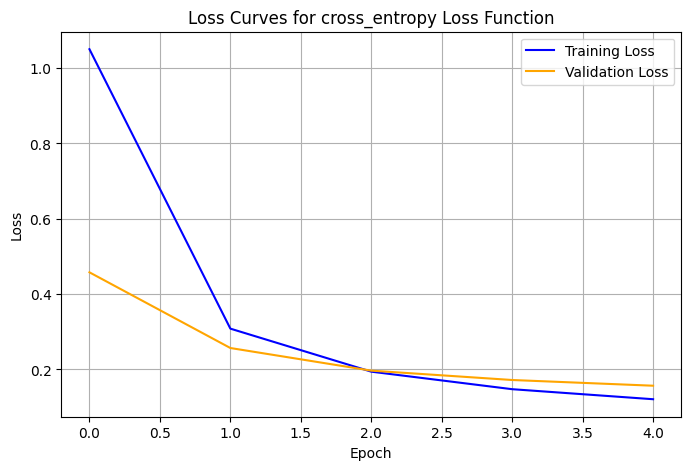

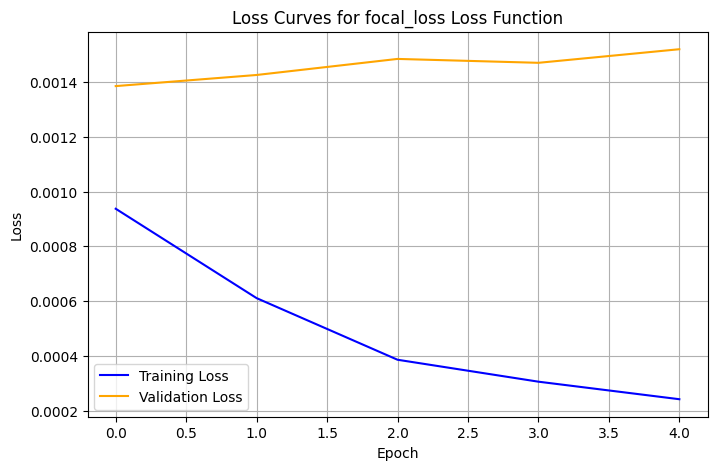

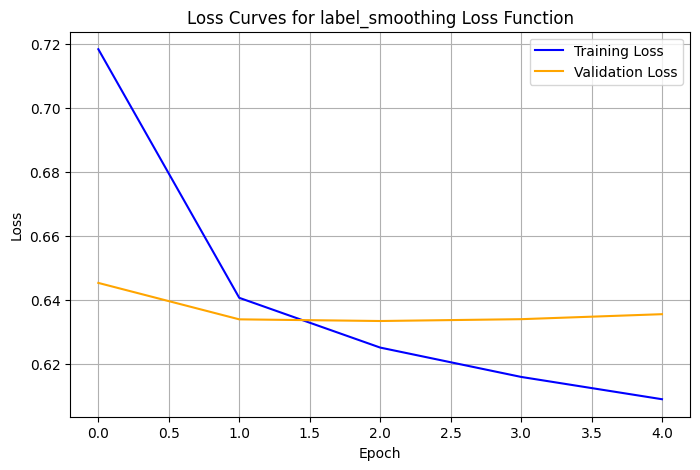

In [25]:
# Plot each training and validation loss curve separately for each loss function
for loss_name, result in results.items():
    plt.figure(figsize=(8, 5))
    plt.plot(result["train_losses"], label="Training Loss", color="blue")
    plt.plot(result["val_losses"], label="Validation Loss", color="orange")
    plt.title(f"Loss Curves for {loss_name} Loss Function")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()


# Analysis of various loss functions
Although Label_smoothing Loss function performs best in terms of metrics it shows overfitting after the first epoch. Therefore, cross entropy loss function seems to be better for our model and dataset.
